In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
meowmeowmeowmeowmeow_gtsrb_german_traffic_sign_path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')

print('Data source import complete.')


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Data source import complete.


# **Traffic Sign Image Classification 97% Acc [CNN]**

![maxresdefault.jpg](attachment:3a42276f-3af1-4c53-87ed-9d0dd201db12.jpg)

1. Download and Imports
2. Functions
3. Loading Dataset (Traffic Signs Images)
4. Data Splitting and conversion
5. Creating and Compiling the Model
6. Training the Model
7. Visualizing the performance of the Model during Training Phase
8. Loading Test Dataset and Evaluating the Model
9. Saving the Model

Note: you will encounter problems if you copy this code to Google Colab, so i made a version for it that i have tried and it's working, here's the link :

on Google Colab : https://colab.research.google.com/drive/1v_ctk-RB3lTf_sCvDSJke9BtdNNZ7Mfg?usp=sharing

Here's the code on Github if you are into that hhhh:

on Github :  https://github.com/yassiracharki/DeepLearningProjrects/blob/main/traffic_sign_image_classification_96_cnn.ipynb

# 1. Download and Imports

In [2]:
# Fundamental classes
import numpy as np
import pandas as pd
import tensorflow as tf
import os

# Image related
import cv2
from PIL import Image

#Performance Plot
from sklearn import metrics
from sklearn.metrics import f1_score, accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# For the model and it's training
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# Time
import time
import datetime

# 2. Functions

In [3]:
# date_time function

def date_time(x):
    if x==1:
        return 'Timestamp: {:%Y-%m-%d %H:%M:%S}'.format(datetime.datetime.now())
    if x==2:
        return 'Timestamp: {:%Y-%b-%d %H:%M:%S}'.format(datetime.datetime.now())
    if x==3:
        return 'Date now: %s' % datetime.datetime.now()
    if x==4:
        return 'Date today: %s' % datetime.date.today()

In [4]:
# Performance Plot

def plot_performance(history=None, figure_directory=None, ylim_pad=[0, 0]):
    xlabel = 'Epoch'
    legends = ['Training', 'Validation']

    plt.figure(figsize=(20, 5))

    y1 = history.history['accuracy']
    y2 = history.history['val_accuracy']

    min_y = min(min(y1), min(y2))-ylim_pad[0]
    max_y = max(max(y1), max(y2))+ylim_pad[0]


    plt.subplot(121)

    plt.plot(y1)
    plt.plot(y2)

    plt.title('Model Accuracy\n'+date_time(1), fontsize=17)
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel('Accuracy', fontsize=15)
    plt.ylim(min_y, max_y)
    plt.legend(legends, loc='upper left')
    plt.grid()

    y1 = history.history['loss']
    y2 = history.history['val_loss']

    min_y = min(min(y1), min(y2))-ylim_pad[1]
    max_y = max(max(y1), max(y2))+ylim_pad[1]


    plt.subplot(122)

    plt.plot(y1)
    plt.plot(y2)

    plt.title('Model Loss\n'+date_time(1), fontsize=17)
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel('Loss', fontsize=15)
    plt.ylim(min_y, max_y)
    plt.legend(legends, loc='upper left')
    plt.grid()
    if figure_directory:
        plt.savefig(figure_directory+"/history")

    plt.show()

In [5]:
!pip install kaggle


In [6]:
from google.colab import files
files.upload()   # choose kaggle.json when the file picker opens


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sudalaimuthumarim","key":"129997abeba15dbd07e846a233e55ba2"}'}

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [9]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -p /content


Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:05<00:00, 108MB/s]



In [14]:
import os
import zipfile

# Unzip the dataset first if it's not already unzipped
zip_path = "/content/gtsrb-german-traffic-sign.zip"
extract_path = "/content/gtsrb"

if not os.path.exists(extract_path):
    print(f"Extracting {zip_path} to {extract_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print(f"Directory {extract_path} already exists. Skipping extraction.")

root = extract_path # Set root to the extracted directory
print("Top-level files/folders:", os.listdir(root)[:50])   # show what’s in /content/gtsrb
print("Train folder exists:", os.path.exists(os.path.join(root, "Train")))
# Changed 'train' to 'Train' to match the actual folder name after extraction
print("Example class-0 path list (first 10):")
print(os.listdir(os.path.join(root, "Train", "0"))[:10])

Extracting /content/gtsrb-german-traffic-sign.zip to /content/gtsrb...
Extraction complete.
Top-level files/folders: ['Train.csv', 'train', 'meta', 'Meta.csv', 'Test', 'Meta', 'Test.csv', 'Train', 'test']
Train folder exists: True
Example class-0 path list (first 10):
['00000_00000_00027.png', '00000_00006_00019.png', '00000_00000_00018.png', '00000_00003_00021.png', '00000_00001_00008.png', '00000_00005_00018.png', '00000_00004_00008.png', '00000_00001_00019.png', '00000_00005_00002.png', '00000_00001_00003.png']


# 3. Loading Dataset (Traffic Signs Images)

In [15]:
# Setting variables for later use
data = []
labels = []
classes = 43
cur_path = os.getcwd()

# Retrieving the images and their labels
for i in range(classes):
    path = os.path.join('/content/gtsrb/Train',str(i))
    images = os.listdir(path)

    for a in images:
        try:
            image = Image.open(path + '/'+ a)
            image = image.resize((30,30))
            image = np.array(image)
            #sim = Image.fromarray(image)
            data.append(image)
            labels.append(i)
        except:
            print("Error loading image")

# Converting lists into numpy arrays
data = np.array(data)
labels = np.array(labels)

In [16]:
# ✅ Class names for prediction output (edit based on your dataset)
class_names = {
    0: "Speed Limit 20 km/h",
    1: "Speed Limit 30 km/h",
    2: "Speed Limit 50 km/h",
    3: "Speed Limit 60 km/h",
    4: "Speed Limit 70 km/h",
    5: "Speed Limit 80 km/h",
    6: "End of Speed Limit 80",
    7: "Speed Limit 100 km/h",
    8: "Speed Limit 120 km/h",
    9: "No passing",
    10: "No passing for vehicles > 3.5t",
    11: "Right of way",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles > 3.5t prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Ice/Snow",
    31: "Wild animals crossing",
    32: "End speed + passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End no passing > 3.5t"
}


# 4. Data Splitting and conversion

In [17]:
# Checking data shape
print(data.shape, labels.shape)

# Splitting training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Displaying the shape after the split
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Converting the labels into one hot encoding
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

(39209, 30, 30, 3) (39209,)
(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


# 5. Creating and Compiling the Model

In [18]:
# Building the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(Conv2D(filters=64, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.15))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.20))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(43, activation='softmax'))

# Compilation of the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#M odel display
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,939 (6.20 MB)

 Trainable params: 1,624,939 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Training the Model

In [19]:
# Training the Model
with tf.device('/GPU:0'):
    epochs = 4
    history1 = model.fit(X_train, y_train, batch_size=128, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/4
246/246 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.6889 - loss: 1.3800 - val_accuracy: 0.9638 - val_loss: 0.1542
Epoch 2/4
246/246 ━━━━━━━━━━━━━━━━━━━━ 241s 982ms/step - accuracy: 0.9531 - loss: 0.1801 - val_accuracy: 0.9833 - val_loss: 0.0719
Epoch 3/4
246/246 ━━━━━━━━━━━━━━━━━━━━ 262s 983ms/step - accuracy: 0.9713 - loss: 0.1078 - val_accuracy: 0.9843 - val_loss: 0.0609
Epoch 4/4
246/246 ━━━━━━━━━━━━━━━━━━━━ 264s 989ms/step - accuracy: 0.9765 - loss: 0.0848 - val_accuracy: 0.9864 - val_loss: 0.0504


# 7. Visualizing the performance of the Model during Training Phase

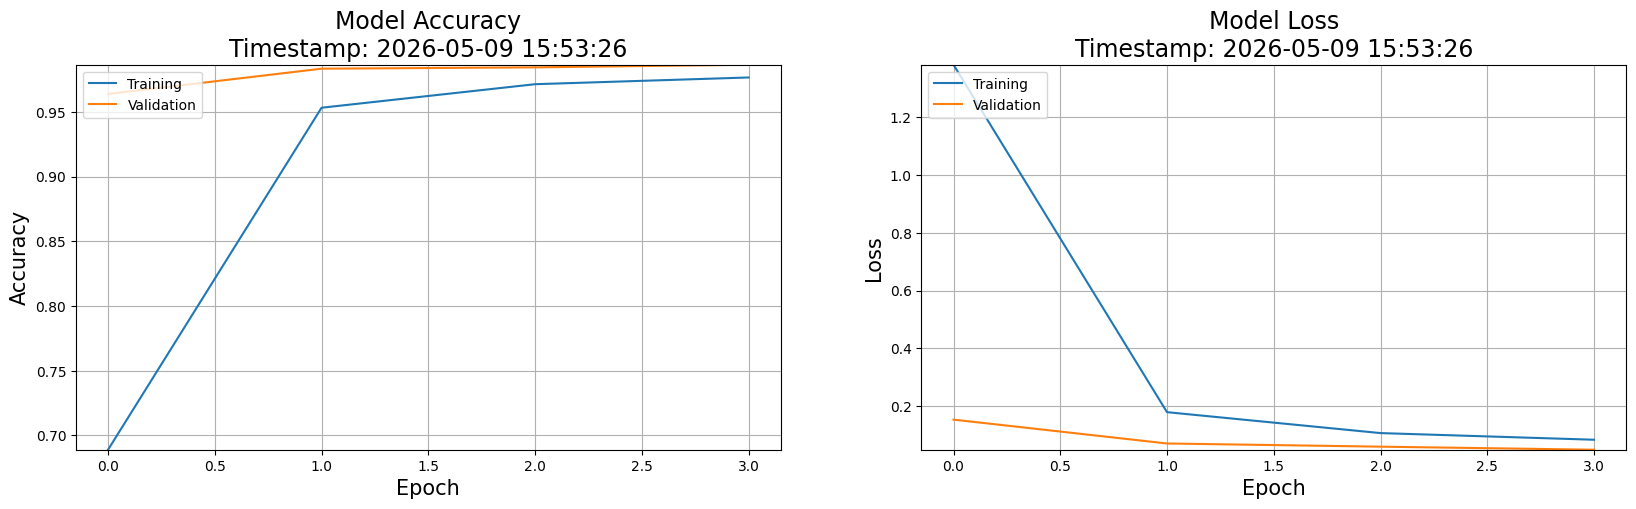

In [20]:
plot_performance(history=history1)

# 8. Loading Test Dataset and Evaluating the Model

In [21]:
# Testing accuracy on test dataset
from sklearn.metrics import accuracy_score

y_test = pd.read_csv('/content/gtsrb/Test.csv')

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data = []

with tf.device('/GPU:0'):
    for img in imgs:
        image = Image.open('/content/gtsrb/' + img)  # ✅ fixed path
        image = image.resize((30, 30))
        data.append(np.array(image))

X_test = np.array(data)


In [22]:
with tf.device('/GPU:0'):
    pred = np.argmax(model.predict(X_test), axis=-1)

#Accuracy with the test data
from sklearn.metrics import accuracy_score
print(accuracy_score(labels, pred))

395/395 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step
0.9622327790973871


# 9. Saving the Model

In [23]:
model.save("traffic_classifier.h5")

In [24]:
# Load the saved model
model = load_model('traffic_classifier.h5')

# Load a sample image for prediction
img = Image.open('/content/gtsrb/Test/00017.png')
img = img.resize((30,30))
img = np.expand_dims(np.array(img), axis=0)

# Predict the class
prediction = np.argmax(model.predict(img), axis=-1)
print("Predicted class:", prediction[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted class: 20


Saving 00012.png to 00012.png


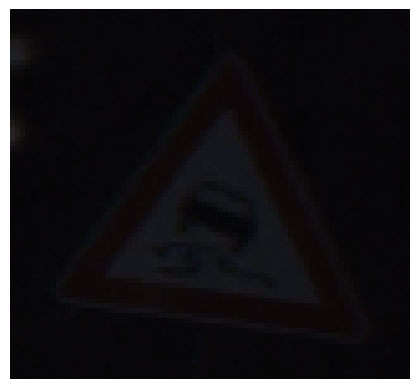

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

Predicted Class Number: 23
Predicted Traffic Sign: Slippery road


In [25]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained model once
model = load_model('traffic_classifier.h5')

uploaded = files.upload()

for file_name in uploaded.keys():
    image = Image.open(file_name)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    img = image.resize((30, 30))
    img = np.expand_dims(np.array(img), axis=0)

    pred = model.predict(img)
    class_index = np.argmax(pred)

    print("\nPredicted Class Number:", class_index)
    print("Predicted Traffic Sign:", class_names[class_index])
